In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import ast
import warnings

In [2]:
df = pd.read_csv('Car_sale_ads.csv')

In [3]:
print(f'Shape of data: {df.shape}')

Shape of data: (208304, 25)


In [4]:
df.head()

,Index,Price,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
0,0,86200,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,1,43500,PLN,Used,Abarth,Other,NaN,NaN,1974,59000.0,...,Manual,coupe,2.0,silver,NaN,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,2,44900,PLN,Used,Abarth,500,NaN,NaN,2018,52000.0,...,Automatic,small_cars,3.0,silver,NaN,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,3,39900,PLN,Used,Abarth,500,NaN,NaN,2012,29000.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,4,97900,PLN,New,Abarth,595,NaN,NaN,2021,600.0,...,Manual,small_cars,3.0,blue,NaN,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208304 entries, 0 to 208303
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    208304 non-null  int64  
 1   Price                    208304 non-null  int64  
 2   Currency                 208304 non-null  object 
 3   Condition                208304 non-null  object 
 4   Vehicle_brand            208304 non-null  object 
 5   Vehicle_model            208304 non-null  object 
 6   Vehicle_version          138082 non-null  object 
 7   Vehicle_generation       147860 non-null  object 
 8   Production_year          208304 non-null  int64  
 9   Mileage_km               207321 non-null  float64
 10  Power_HP                 207661 non-null  float64
 11  Displacement_cm3         206338 non-null  float64
 12  Fuel_type                208304 non-null  object 
 13  CO2_emissions            94047 non-null   float64
 14  Driv

In [12]:
df.isnull().sum()

Index                           0
Price                           0
Currency                        0
Condition                       0
Vehicle_brand                   0
Vehicle_model                   0
Vehicle_version             70222
Vehicle_generation          60444
Production_year                 0
Mileage_km                    983
Power_HP                      643
Displacement_cm3             1966
Fuel_type                       0
CO2_emissions              114257
Drive                       15076
Transmission                  479
Type                            0
Doors_number                 1487
Colour                          0
Origin_country              89992
First_owner                143210
First_registration_date    121859
Offer_publication_date          0
Offer_location                  0
Features                        0
dtype: int64

In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,208304.0,NaN,NaN,NaN,104151.5,60132.329574,0.0,52075.75,104151.5,156227.25,208303.0
Price,208304.0,NaN,NaN,NaN,63053.833714,86659.67269,500.0,17800.0,35700.0,75990.0,6999000.0
Currency,208304,2,PLN,208034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,208304,2,Used,182850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_brand,208304,108,Volkswagen,18455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_model,208304,1203,Astra,5302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_version,138082,19056,2.0 TDI,888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_generation,147860,569,II (2012-),3758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_year,208304.0,NaN,NaN,NaN,2012.098241,6.998414,1915.0,2008.0,2013.0,2017.0,2021.0
Mileage_km,207321.0,NaN,NaN,NaN,150276.76396,2937446.805427,1.0,53000.0,144566.0,206000.0,1111111111.0


In [16]:
print("COLUMN TYPES & VALUE COUNTS")

for col in df.columns:
    counts = df[col].value_counts()
    print(f"\nColumn: {col} ({df[col].dtype})")
    print(counts)

COLUMN TYPES & VALUE COUNTS

Column: Index (int64)
Index
0         1
138873    1
138863    1
138864    1
138865    1
         ..
69437     1
69438     1
69439     1
69440     1
208303    1
Name: count, Length: 208304, dtype: int64

Column: Price (int64)
Price
19900     2277
29900     1894
16900     1833
17900     1779
18900     1731
          ... 
242138       1
80850        1
125487       1
58934        1
154480       1
Name: count, Length: 14142, dtype: int64

Column: Currency (object)
Currency
PLN    208034
EUR       270
Name: count, dtype: int64

Column: Condition (object)
Condition
Used    182850
New      25454
Name: count, dtype: int64

Column: Vehicle_brand (object)
Vehicle_brand
Volkswagen    18455
BMW           16983
Audi          16730
Opel          16322
Ford          16007
              ...  
FAW               1
MAN               1
Talbot            1
NSU               1
Vanderhall        1
Name: count, Length: 108, dtype: int64

Column: Vehicle_model (object)
Vehicle_model

In [25]:
df['Currency'].value_counts()

Currency
PLN    208034
EUR       270
Name: count, dtype: int64

It would be more accurate to convert EUR to PLN, since the number of observations in EUR (270) is much smaller than the number of observations in PLN (208,034)

The current exchange rate is approximately:

**1 EUR ≈ 4.27 Polish złoty (PLN)**

In [28]:
EUR_TO_PLN = 4.27
df['Price_PLN'] = np.where(df['Currency'] == 'EUR', df['Price'] * EUR_TO_PLN, df['Price'])

In [31]:
df['Offer_publication_date'].value_counts()

Offer_publication_date
03/05/2021    26561
30/04/2021    26535
02/05/2021    26146
04/05/2021    25895
29/04/2021    25090
01/05/2021    24630
28/04/2021    13533
26/04/2021    13010
27/04/2021    11902
25/04/2021    10022
24/04/2021     2105
23/04/2021      672
22/04/2021      670
21/04/2021      585
20/04/2021      508
19/04/2021      143
15/04/2021       46
16/04/2021       34
05/05/2021       31
17/04/2021       29
18/04/2021       27
13/04/2021       15
14/04/2021       14
07/04/2021       13
12/04/2021       12
06/04/2021       11
10/04/2021       11
05/04/2021       10
08/04/2021        9
11/04/2021        8
09/04/2021        8
04/04/2021        7
28/03/2021        2
31/03/2021        2
02/04/2021        2
27/03/2021        1
03/04/2021        1
29/03/2021        1
26/03/2021        1
01/04/2021        1
30/03/2021        1
Name: count, dtype: int64

In [33]:
df['First_registration_date'].value_counts()

First_registration_date
01/01/2017    216
01/01/2016    211
01/01/2015    210
01/01/2018    196
01/01/2014    184
             ... 
03/06/1993      1
25/09/1986      1
20/11/0208      1
12/07/2000      1
04/01/1988      1
Name: count, Length: 8441, dtype: int64

In [36]:
df['Offer_publication_date'] = pd.to_datetime(df['Offer_publication_date'], format='%d/%m/%Y', errors='coerce')
df['First_registration_date'] = pd.to_datetime(df['First_registration_date'], format='%d/%m/%Y', errors='coerce')

In [38]:
df['First_registration_date'].value_counts()

First_registration_date
2017-01-01    216
2016-01-01    211
2015-01-01    210
2018-01-01    196
2014-01-01    184
             ... 
2021-02-14      1
1996-10-22      1
1989-09-01      1
2001-03-04      1
1988-01-04      1
Name: count, Length: 8244, dtype: int64

In [40]:
df['Generation_start_year'] = (
    df['Vehicle_generation']
    .str.extract(r'\((\d{4})', expand=False)
    .astype('Int64')
)

<Axes: >

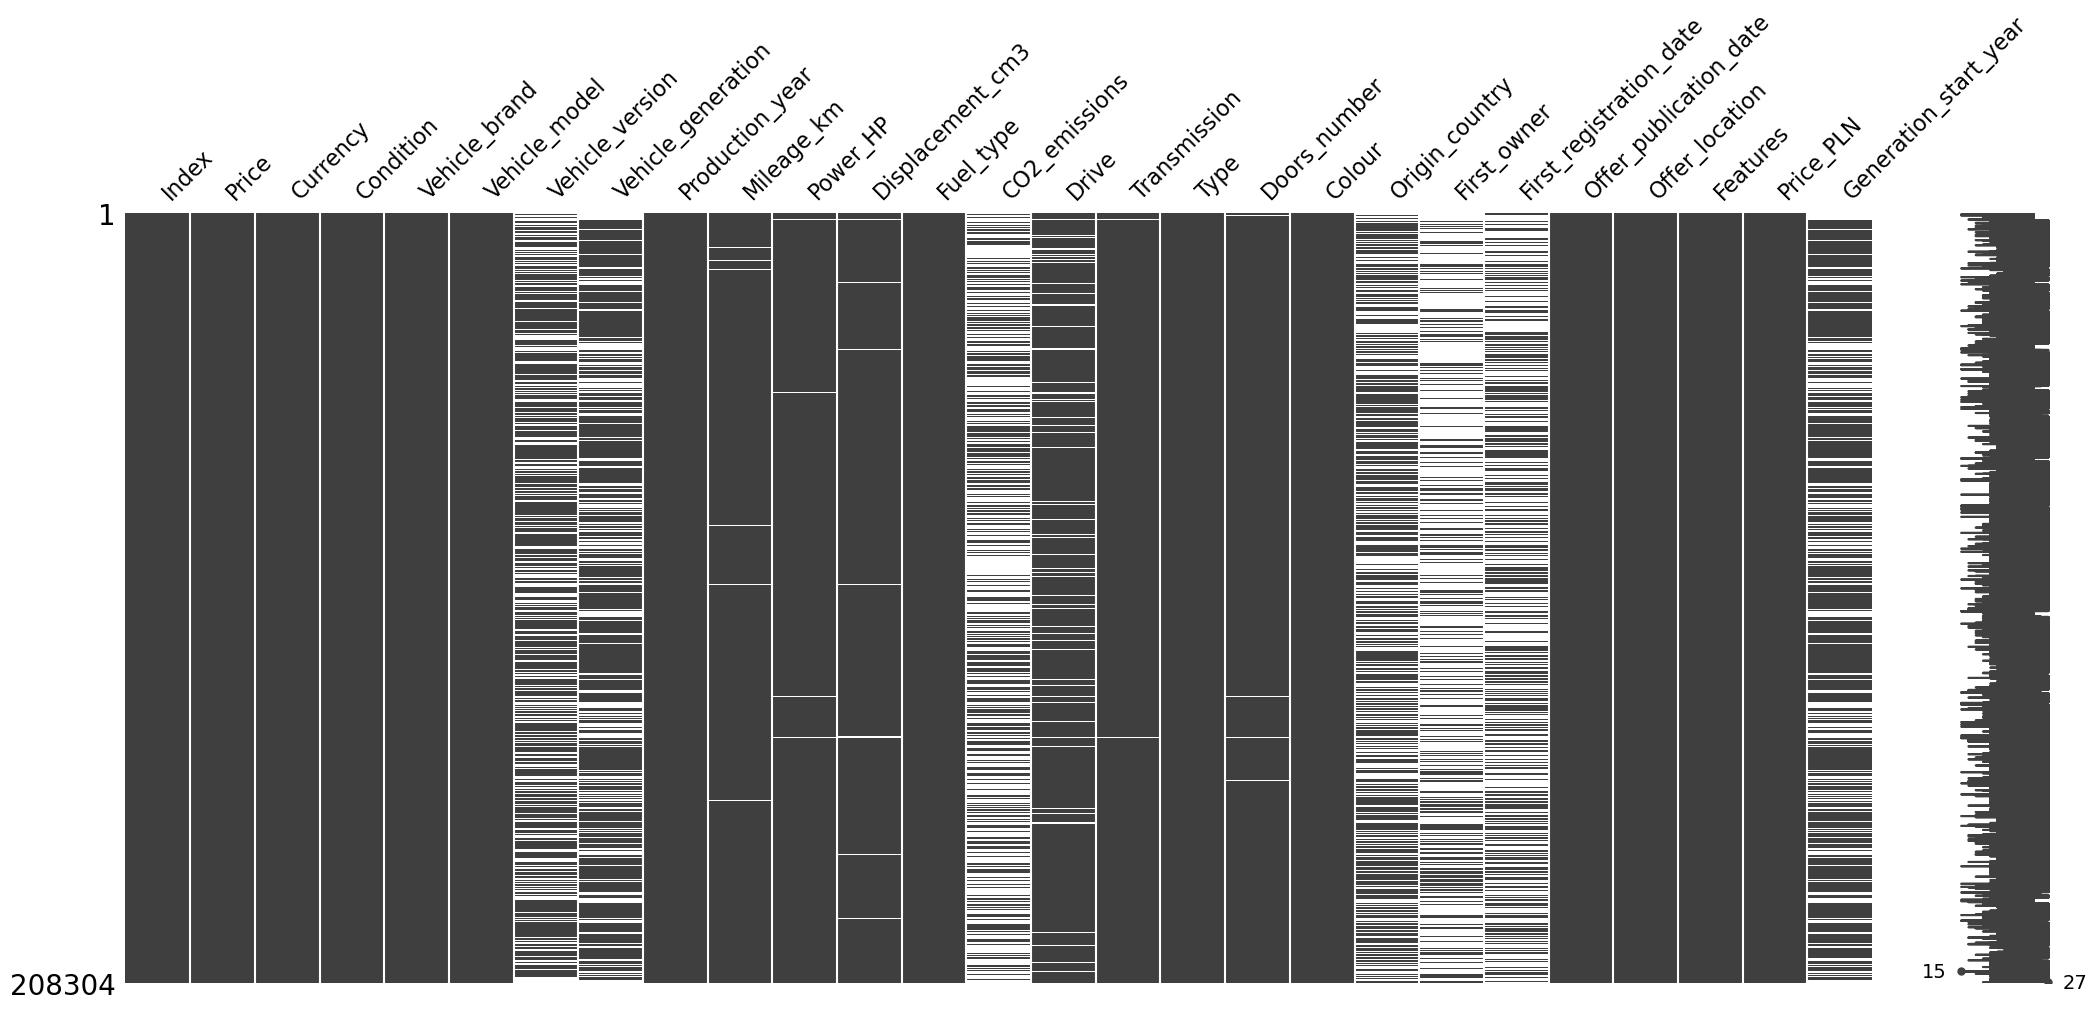

In [43]:
msno.matrix(df)

<Axes: >

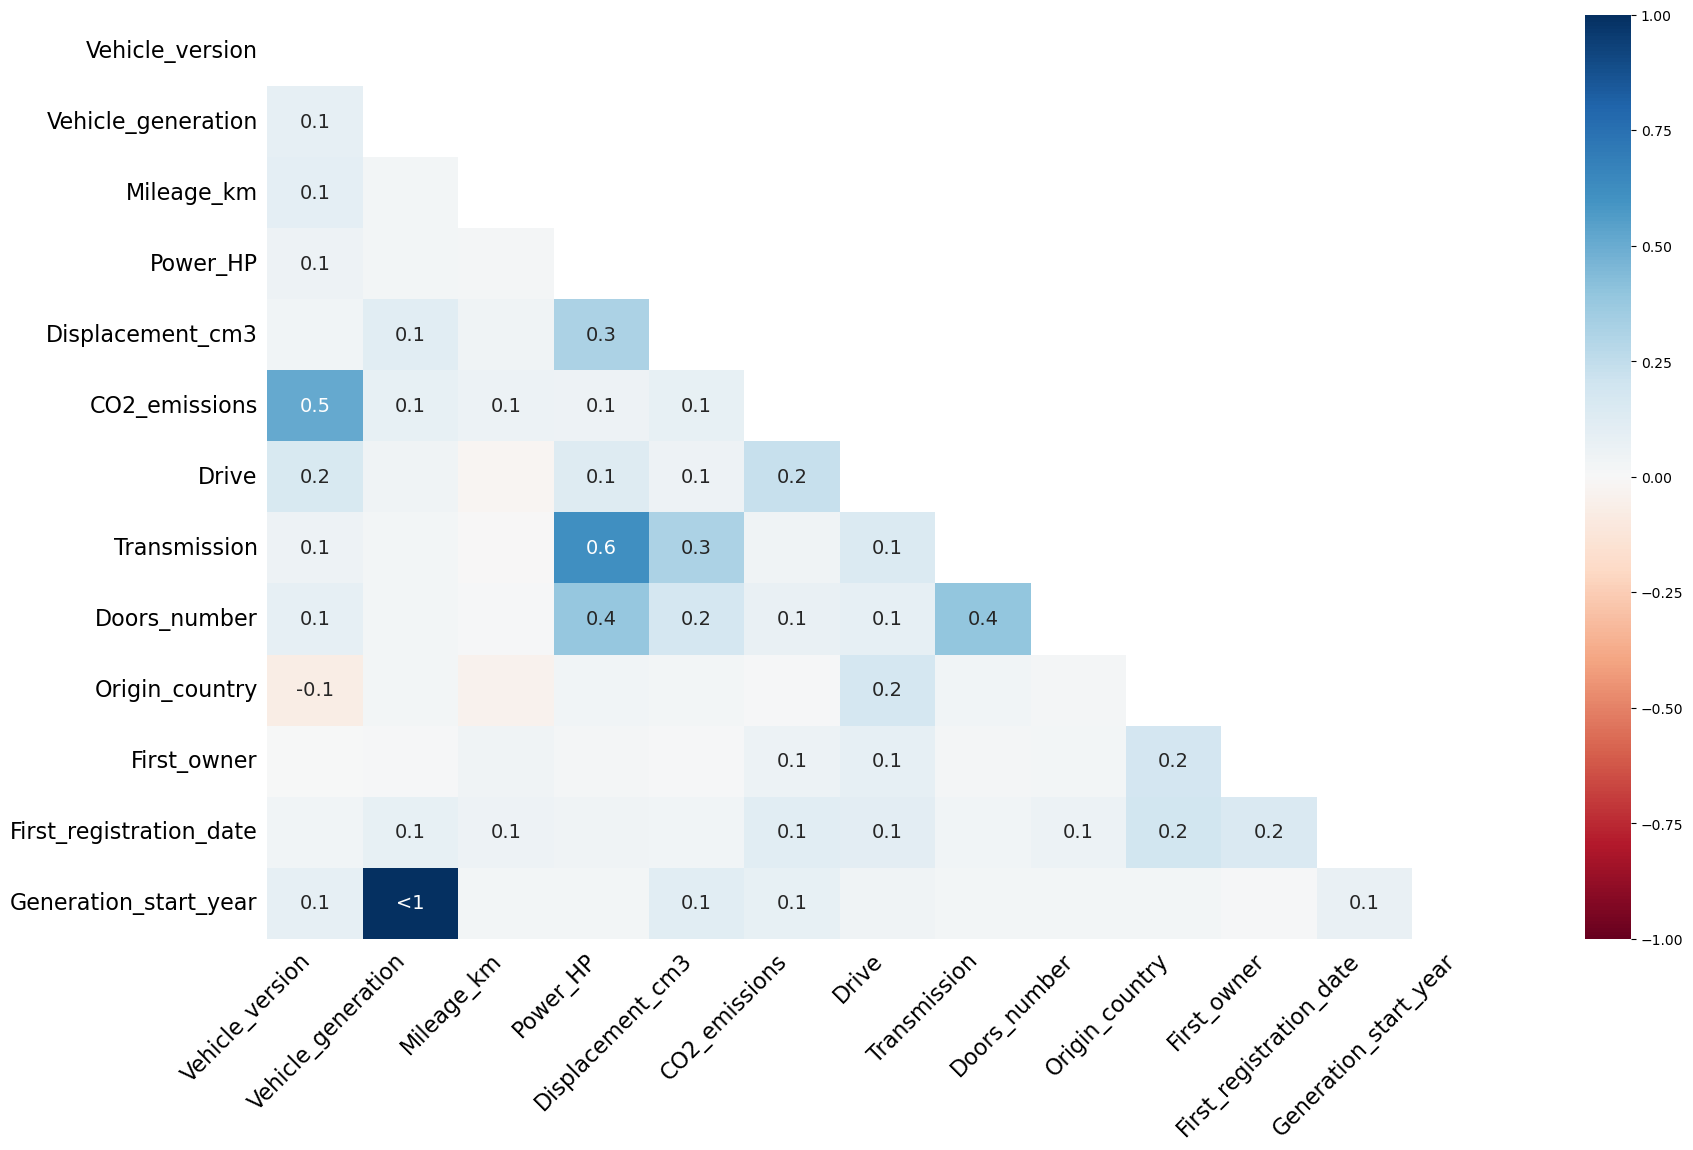

In [45]:
msno.heatmap(df)

<Axes: >

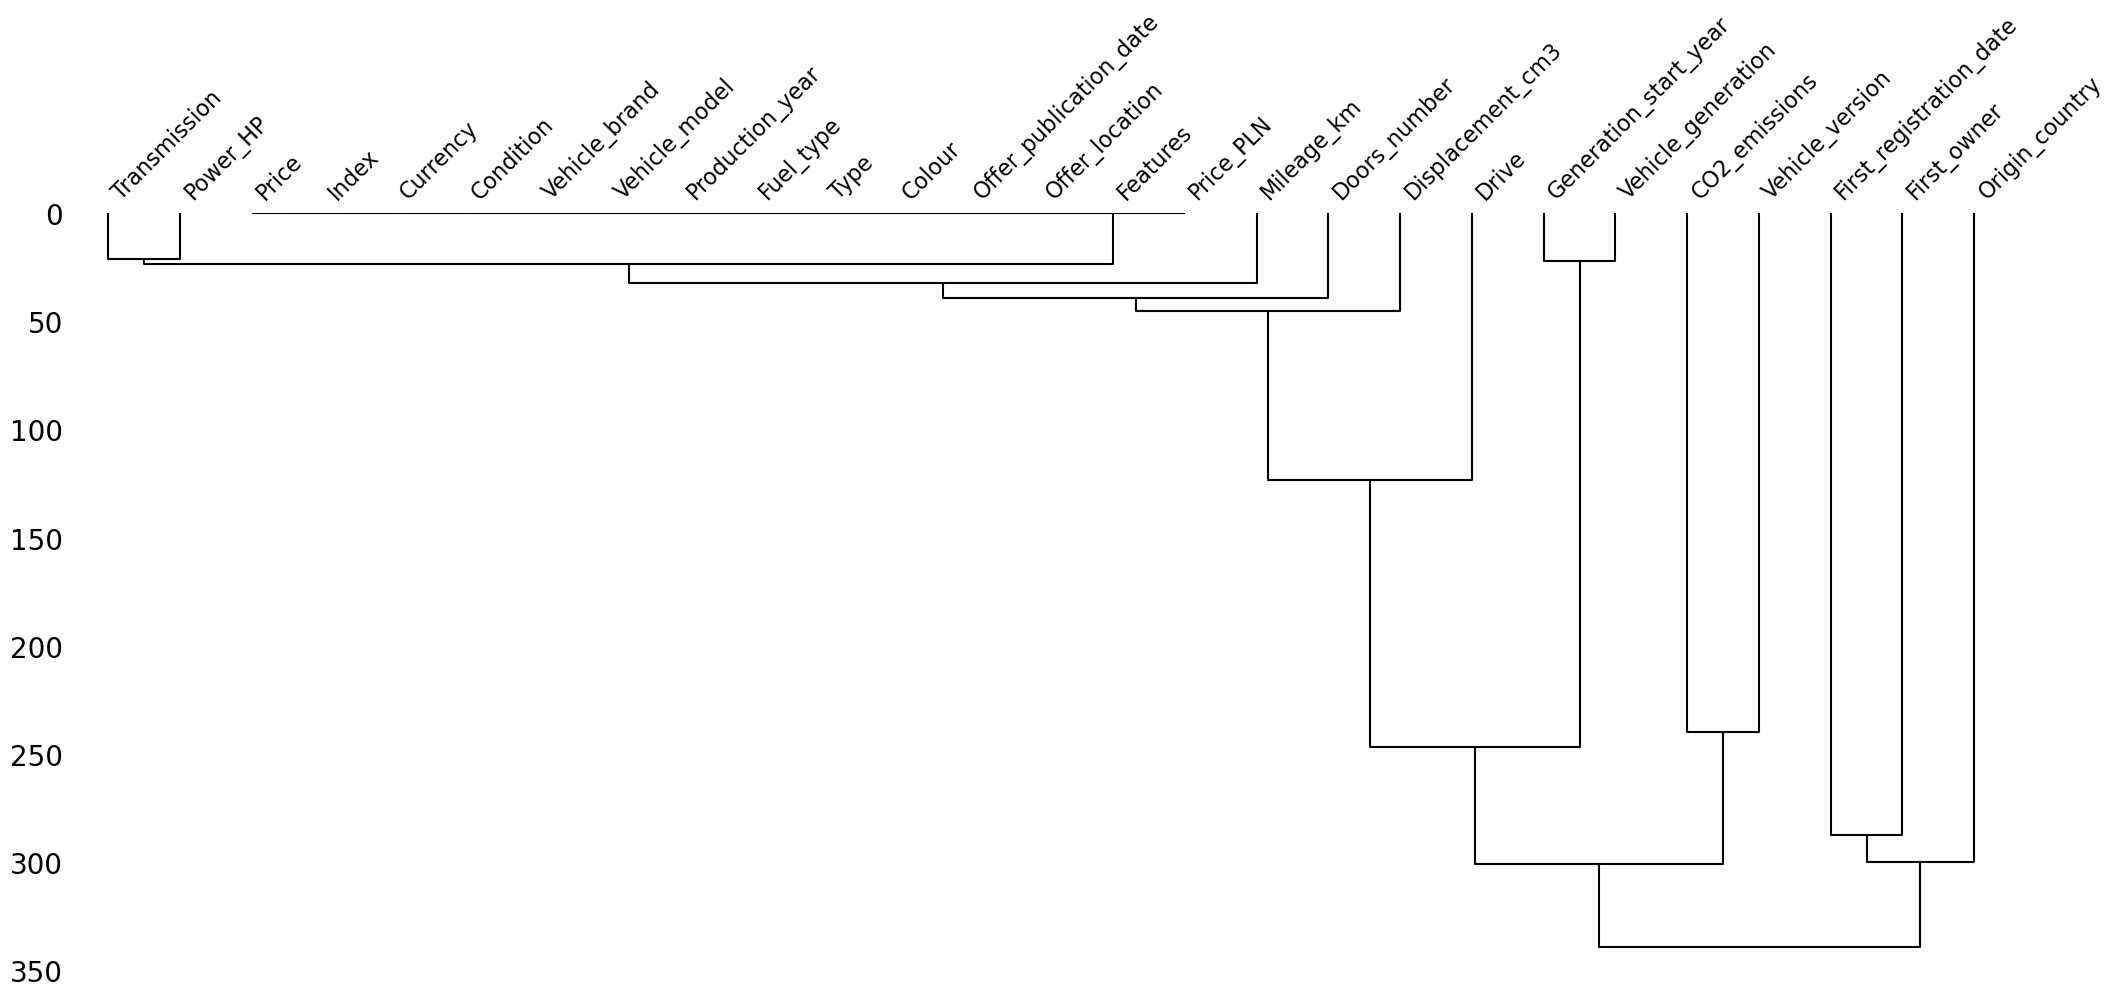

In [46]:
msno.dendrogram(df)

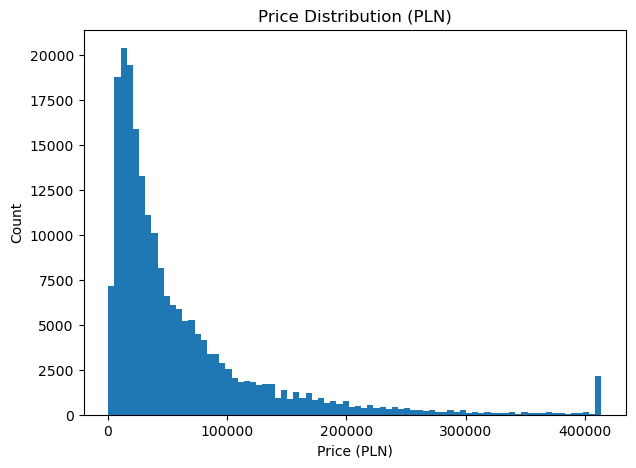

In [51]:
plt.figure(figsize=(7,5))

plt.hist(
    df['Price_PLN'].clip(upper=df['Price_PLN'].quantile(0.99)),
    bins=80
)

plt.title('Price Distribution (PLN)')
plt.xlabel('Price (PLN)')
plt.ylabel('Count')

plt.show()

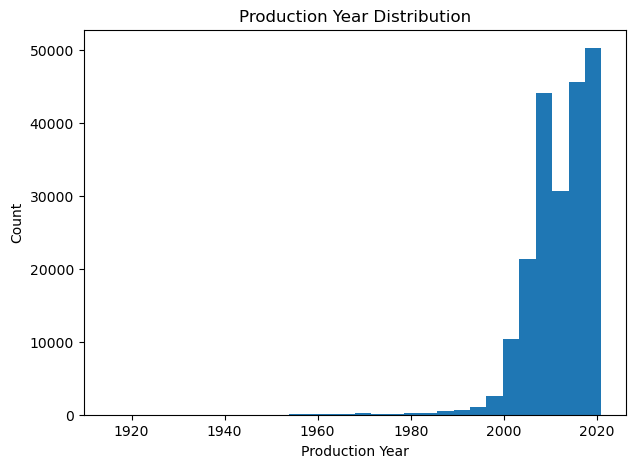

In [53]:
plt.figure(figsize=(7,5))

plt.hist(df['Production_year'].dropna(), bins=30)

plt.title('Production Year Distribution')
plt.xlabel('Production Year')
plt.ylabel('Count')

plt.show()

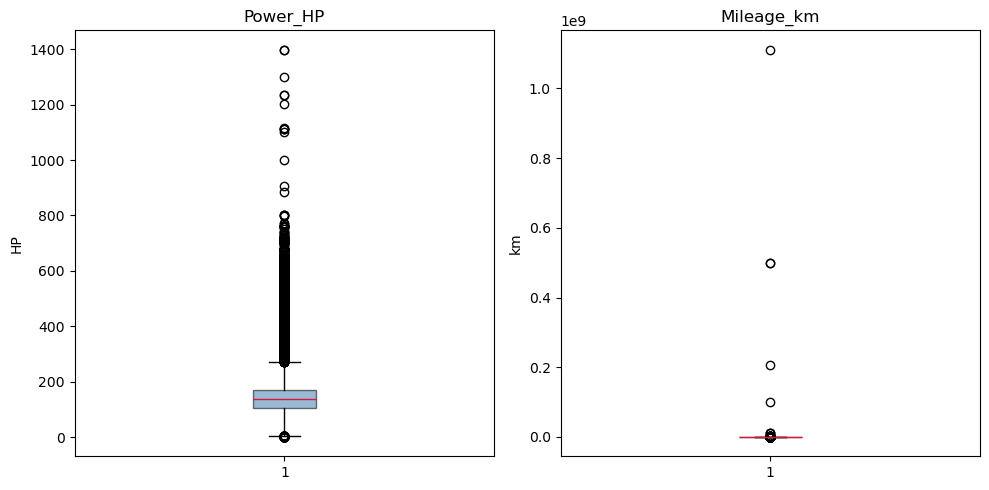

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].boxplot(
    df['Power_HP'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.55),
    medianprops=dict(color='crimson')
)
axes[0].set_title('Power_HP')
axes[0].set_ylabel('HP')

axes[1].boxplot(
    df['Mileage_km'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.55),
    medianprops=dict(color='crimson')
)
axes[1].set_title('Mileage_km')
axes[1].set_ylabel('km')

plt.tight_layout()
plt.show()

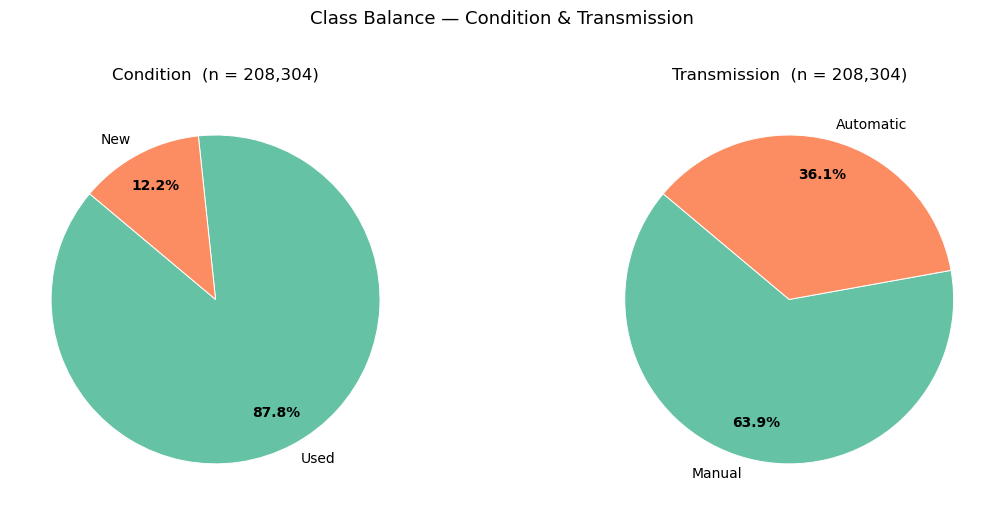

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = plt.get_cmap('Set2')

for ax, col in zip(axes, ['Condition', 'Transmission']):
    vc = df[col].value_counts()
    colors = [cmap(i) for i in range(len(vc))]
    wedges, texts, autotexts = ax.pie(
        vc.values, labels=vc.index, autopct='%1.1f%%',
        startangle=140, pctdistance=0.78, colors=colors,
        wedgeprops=dict(linewidth=0.7, edgecolor='white')
    )
    for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
    for t  in texts:     t.set_fontsize(10)
    ax.set_title(f'{col}  (n = {len(df):,})', fontsize=12, pad=10)

fig.suptitle('Class Balance — Condition & Transmission', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


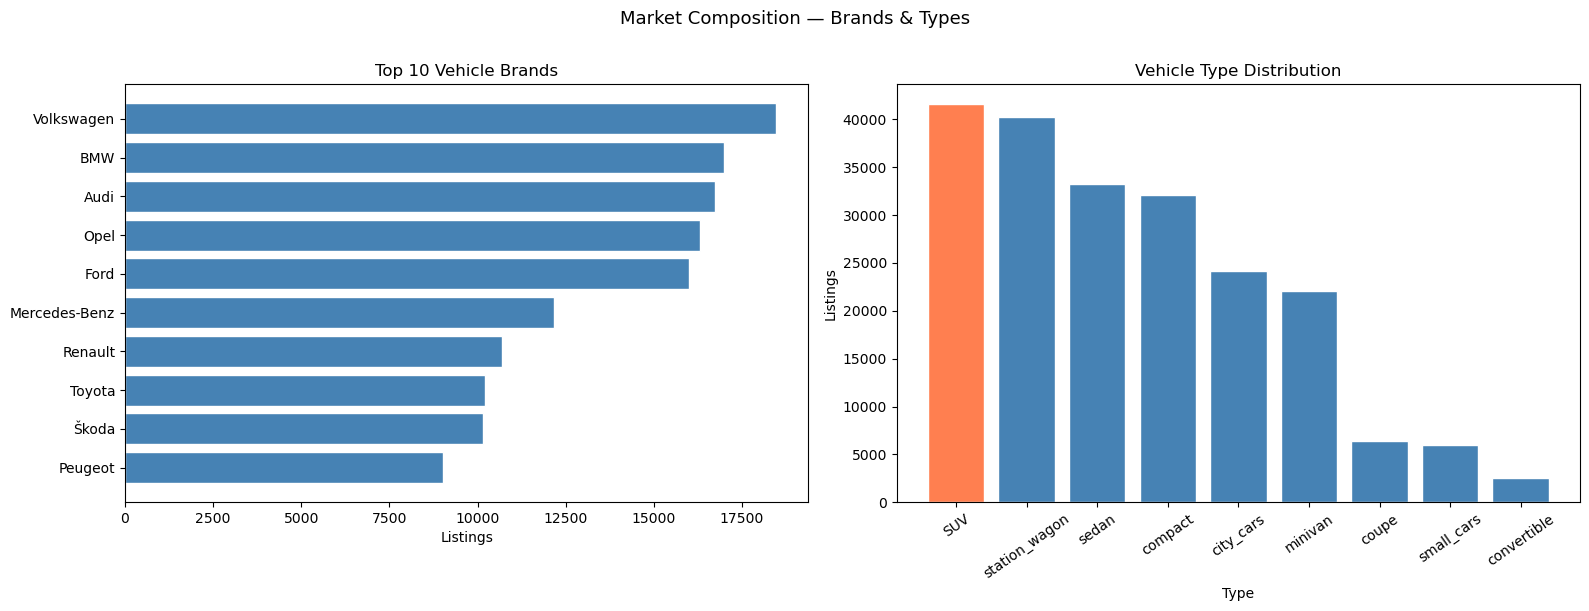

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 brands
top_brands = df['Vehicle_brand'].value_counts().head(10)
axes[0].barh(top_brands.index[::-1], top_brands.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Vehicle Brands')
axes[0].set_xlabel('Listings')

type_counts = df['Type'].value_counts()
colors = ['coral' if t == type_counts.idxmax() else 'steelblue' for t in type_counts.index]
axes[1].bar(type_counts.index, type_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Vehicle Type Distribution')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Listings')
axes[1].tick_params(axis='x', rotation=35)

fig.suptitle('Market Composition — Brands & Types', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

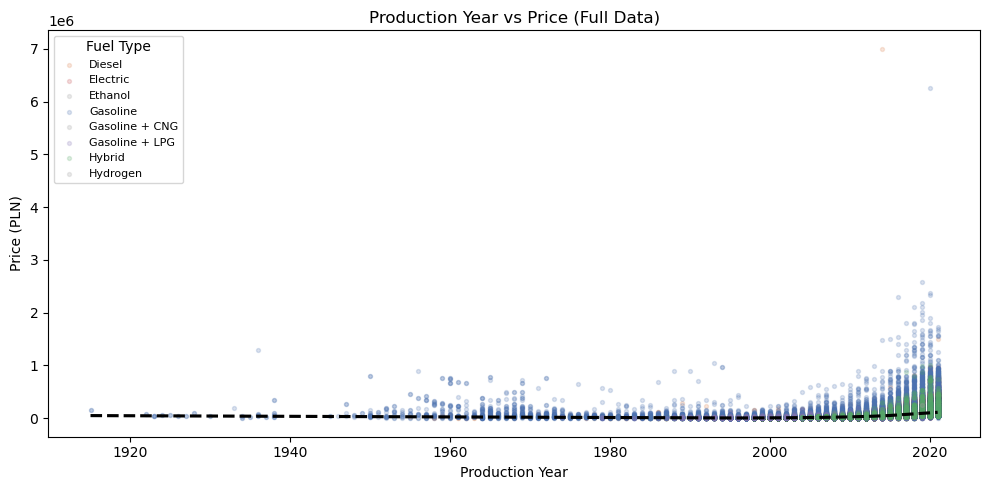

In [65]:
fig, ax = plt.subplots(figsize=(10,5))

fuel_palette = {
    'Gasoline': '#4C72B0', 'Diesel': '#DD8452',
    'Hybrid': '#55A868', 'Electric': '#C44E52',
    'Gasoline + LPG': '#8172B2', 'Other': '#999999'
}

scatter_df = df[df['Mileage_km'].notna()]

for fuel, grp in scatter_df.groupby('Fuel_type'):
    ax.scatter(
        grp['Production_year'],
        grp['Price_PLN'],
        s=8,
        alpha=0.2,
        color=fuel_palette.get(fuel, '#999999'),
        label=fuel
    )

import warnings; warnings.filterwarnings('ignore')

sns.regplot(
    data=scatter_df,
    x='Production_year',
    y='Price_PLN',
    scatter=False,
    color='black',
    lowess=True,
    line_kws={'linestyle':'--'}
)

ax.set_xlabel('Production Year')
ax.set_ylabel('Price (PLN)')
ax.set_title('Production Year vs Price (Full Data)')
ax.legend(title='Fuel Type', fontsize=8)

plt.tight_layout()
plt.show()

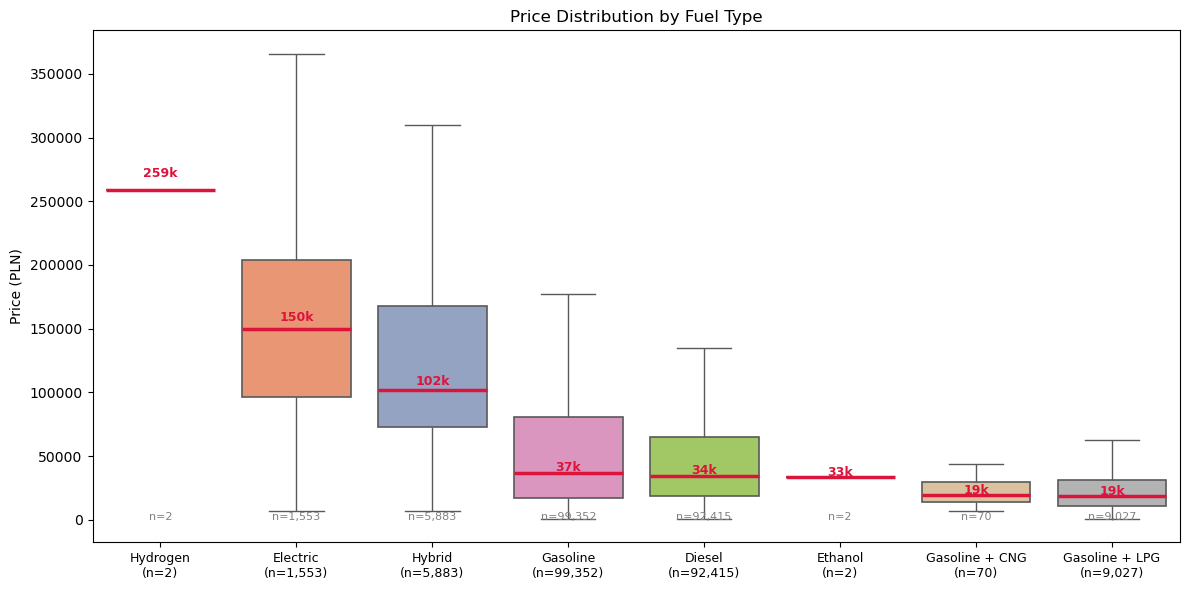

In [66]:
fuel_order = df.groupby('Fuel_type')['Price_PLN'].median().sort_values(ascending=False).index
fuel_counts = df['Fuel_type'].value_counts()

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Fuel_type',
    y='Price_PLN',
    order=fuel_order,
    palette='Set2',
    showfliers=False,
    boxprops=dict(linewidth=1.2),
    medianprops=dict(color='crimson', linewidth=2.5)
)

plt.title('Price Distribution by Fuel Type', fontsize=12)
plt.xlabel('')
plt.ylabel('Price (PLN)')

medians = df.groupby('Fuel_type')['Price_PLN'].median()
for i, fuel in enumerate(fuel_order):
    med = medians[fuel]
    n = fuel_counts.get(fuel, 0)
    plt.text(i, med*1.04, f'{med/1000:.0f}k', ha='center', color='crimson', fontweight='bold', fontsize=9)
    plt.text(i, 0, f'n={n:,}', ha='center', color='gray', fontsize=8)

plt.xticks(range(len(fuel_order)), [f"{f}\n(n={fuel_counts.get(f,0):,})" for f in fuel_order], fontsize=9)

plt.tight_layout()
plt.show()

## Identifying possible insights and directions for a final project

Based on the initial data exploration, this dataset can be used for several projects:

**Used Car Price Prediction**: Building a regression model to estimate the fair market value of a vehicle. By analyzing features like Production_year, Mileage_km, and Power_HP, we can predict prices to help buyers and sellers make data-driven decisions.

**Fuel Type Classification**: Using technical specifications (like engine displacement and CO2 emissions) to classify a car’s fuel type.